# Using the MAST API to resolve KOI into KIC to load LCs

In [1]:
import lightkurve as lk
import matplotlib.pyplot as plt
import requests
import pandas as pd
from time import perf_counter

%matplotlib inline


/Users/wayfinder/Code/fault-in-our-stars/.env/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
sampleKOI = "K00812.01"


In [3]:
start = perf_counter()

# Resolve KOI -> Kepler ID / canonical name using Exo.MAST
info = requests.get(
    "https://exo.mast.stsci.edu/api/v0.1/exoplanets/identifiers/",
    params={"name": sampleKOI},
    timeout=30,
).json()

end = perf_counter()


In [4]:
def query(KOI):
    # Resolve KOI -> Kepler ID / canonical name using Exo.MAST
    info = requests.get(
        "https://exo.mast.stsci.edu/api/v0.1/exoplanets/identifiers/",
        params={"name": KOI},
        timeout=30,
    ).json()
    
    return info


In [5]:
info


{'canonicalName': 'Kepler-235 b',
 'starName': 'Kepler-235',
 'ra': 286.079103,
 'dec': 39.278313,
 'planetNames': ['KIC 4139816 b',
  'Kepler-235 b',
  'KOI 812 b',
  '2MASS J19041898+3916419 b'],
 'keplerID': 4139816,
 'keplerTCE': 'TCE_1',
 'tessID': 120765183,
 'tessTCE': None}

In [6]:
print(f"{end - start:4f}s")


0.508584s


In [7]:
search = lk.search_lightcurve(
    f"KIC {info['keplerID']}",
    mission="Kepler"
)
search


#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,Kepler Quarter 01,2009,Kepler,1800,kplr004139816,0.0
1,Kepler Quarter 02,2009,Kepler,1800,kplr004139816,0.0
2,Kepler Quarter 03,2009,Kepler,1800,kplr004139816,0.0
3,Kepler Quarter 04,2010,Kepler,1800,kplr004139816,0.0
4,Kepler Quarter 05,2010,Kepler,1800,kplr004139816,0.0
5,Kepler Quarter 06,2010,Kepler,1800,kplr004139816,0.0
6,Kepler Quarter 07,2010,Kepler,1800,kplr004139816,0.0
7,Kepler Quarter 11,2011,Kepler,60,kplr004139816,0.0
8,Kepler Quarter 11,2011,Kepler,60,kplr004139816,0.0


In [8]:
def fetchLightCurveCollectionKepler(KIC):
    search = lk.search_lightcurve(
        f"KIC {KIC}",
        mission="Kepler",
        author="Kepler",
        cadence="long"
    )

    return search.download_all().stitch()


Get light curve using KOI by resolving into KIC

In [9]:
queryObject = query(sampleKOI)
sampleKIC = queryObject['keplerID']
lc = fetchLightCurveCollectionKepler(sampleKIC)


<Axes: xlabel='Time - 2454833 [BKJD days]', ylabel='Normalized Flux'>

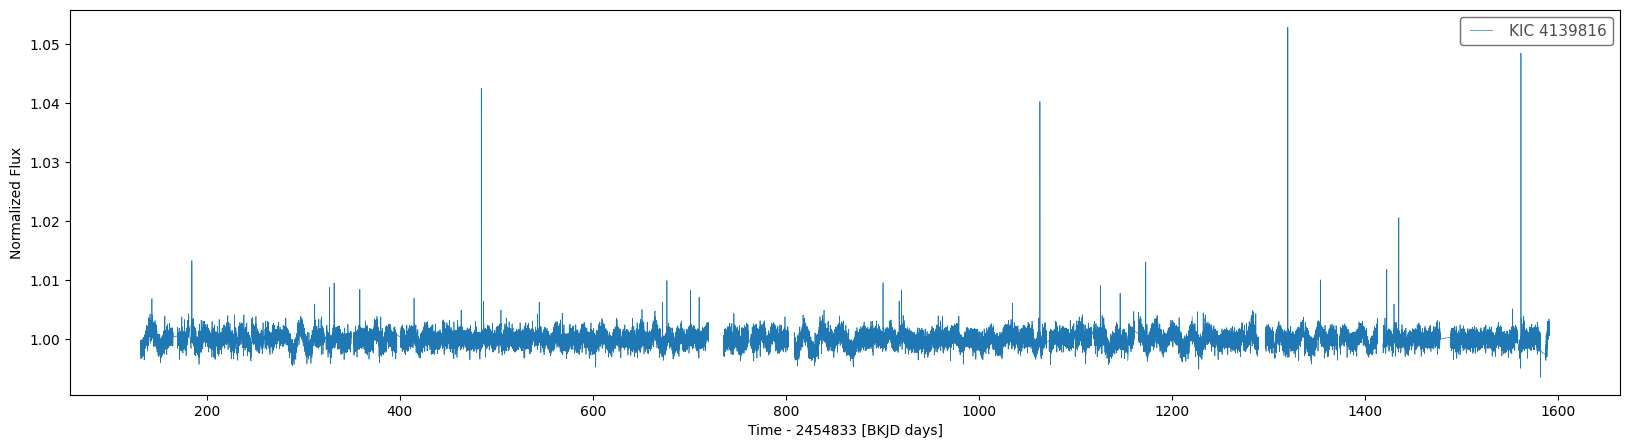

In [17]:
fig, ax = plt.subplots(figsize=(20, 5))
lc.plot(ax=ax)
